# Query Types

The `QueryDtype` is a new addition that specializes in columns of `oechem.OEQMol` types. This is useful for columns of SMARTS or SMIRKS patterns.

In [1]:
import cnotebook
import oepandas as oepd
import pandas as pd
from openeye import oedepict

Let's start out with a list of reactions and their associated reaction schemes in defined in SMIRKS.

In [2]:
reactions_data = {
    "Name": [
        "Amide Coupling",
        "Esterification",
        "N-Alkylation",
        "Suzuki Coupling",
        "Boc Deprotection"
    ],
    "SMIRKS": [
        "[C:1](=[O:2])[OH1].[N!H0:3]>>[C:1](=[O:2])[N:3]",
        "[C:1](=[O:2])[OH1].[O!H0:3]>>[C:1](=[O:2])[O:3]",
        "[N!H0:1].[C:2]-[Cl,Br,I]>>[N:1]-[C:2]",
        "[c:1]-[Cl,Br,I].[c:2]-[B](O)O>>[c:1]-[c:2]",
        "[N:1]-C(=O)-O-C(C)(C)C>>[N:1]"
    ]
}

df = pd.DataFrame(reactions_data)

df.head()

,Name,SMIRKS
0,Amide Coupling,[C:1](=[O:2])[OH1].[N!H0:3]>>[C:1](=[O:2])[N:3]
1,Esterification,[C:1](=[O:2])[OH1].[O!H0:3]>>[C:1](=[O:2])[O:3]
2,N-Alkylation,"[N!H0:1].[C:2]-[Cl,Br,I]>>[N:1]-[C:2]"
3,Suzuki Coupling,"[c:1]-[Cl,Br,I].[c:2]-[B](O)O>>[c:1]-[c:2]"
4,Boc Deprotection,[N:1]-C(=O)-O-C(C)(C)C>>[N:1]


Let's visualize the reactions in 3 easy steps:

1. Use the ``as_query`` function to render the SMIRKS into a column with ``QueryDtype``. The column is now populated by ``oechem.OEQMol`` objects.
2. Set the rendering options for that column to make the images a bit bigger
3. Display it!

,Name,SMIRKS,Reaction
0,Amide Coupling,[C:1](=[O:2])[OH1].[N!H0:3]>>[C:1](=[O:2])[N:3],
1,Esterification,[C:1](=[O:2])[OH1].[O!H0:3]>>[C:1](=[O:2])[O:3],
2,N-Alkylation,"[N!H0:1].[C:2]-[Cl,Br,I]>>[N:1]-[C:2]",
3,Suzuki Coupling,"[c:1]-[Cl,Br,I].[c:2]-[B](O)O>>[c:1]-[c:2]",
4,Boc Deprotection,[N:1]-C(=O)-O-C(C)(C)C>>[N:1],

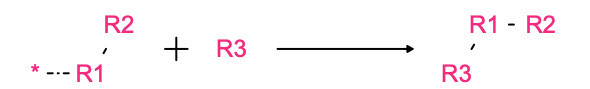
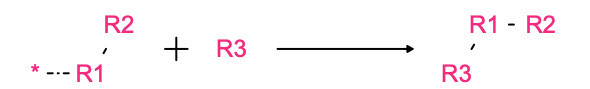
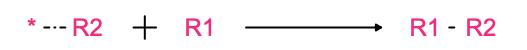
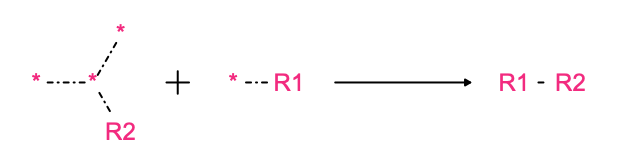
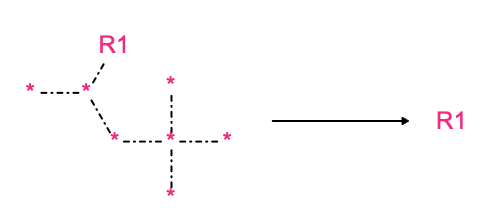

In [5]:
# Converts to a query column
df["Reaction"] = df.SMIRKS.chem.as_query(no_title=True)

# Set the rendering options for the column
df.Reaction.chem.set_render_options(structure_scale=1.5)

# Display it!
df

You can easily use `oechem.OEQMol` the objects in that column for anything you like!